In [1]:
import numpy as np

def simulate_non_beta_data(n_problems=2000, attempts_per_problem=10, random_state=42):
    rng = np.random.default_rng(random_state)
    true_thetas = np.zeros(n_problems)
    
    rand_draws = rng.random(n_problems)
    mask_hard = rand_draws < 0.50
    mask_easy = (rand_draws >= 0.50) & (rand_draws < 0.70)
    mask_mid  = rand_draws >= 0.70
    
    # 3-component mixture on [0,1]:
    # 0.5 * Beta(0.16, 79.84) + 0.25 * Beta(450.3, 23.7) + 0.25 * Beta(1, 1)
    true_thetas[mask_hard] = rng.beta(0.16, 79.84, size=np.sum(mask_hard))
    true_thetas[mask_easy] = rng.beta(450.3, 23.7, size=np.sum(mask_easy))
    true_thetas[mask_mid] = 0.20 + 0.40 * rng.uniform(size=np.sum(mask_mid))
    
    attempts = np.full(n_problems, attempts_per_problem)
    successes = rng.binomial(n=attempts, p=true_thetas)
    return true_thetas, successes, attempts

# Simulate
true_thetas, successes, attempts = simulate_non_beta_data(n_problems=128, attempts_per_problem=64, random_state=999)

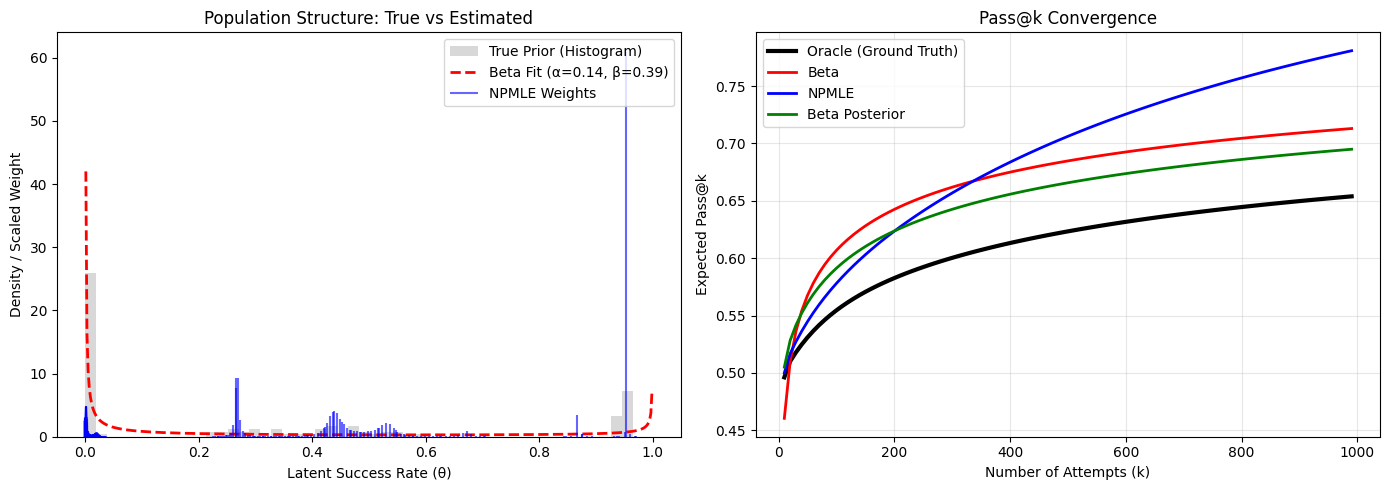

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import beta
# Fit
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK, BetaMixtureNPMLEPassAtK
beta_est = BetaBinomialPassAtK(verbose=False).fit(successes, attempts)
beta_mixture_est = BetaMixtureNPMLEPassAtK(verbose=False, nu=8.0).fit(successes, attempts)
npmle_est = NPMLEBinomialPassAtK(m_grid=300, reg_alpha=0.001, verbose=False).fit(successes, attempts)

# Predict over a smooth range of k
k_eval = np.arange(10, 1000, 10)
oracle_pass_at_k = [1.0 - np.mean((1.0 - true_thetas)**k) for k in k_eval]
beta_pass_at_k = beta_est.predict(k_eval)
npmle_pass_at_k = npmle_est.predict(k_eval)
beta_pass_at_k_posterior = beta_est.predict(k_eval, method="posterior")
beta_mixture_pass_at_k = beta_mixture_est.predict(k_eval, method='integrated')
beta_mixture_pass_at_k_posterior = beta_mixture_est.predict(k_eval, method="posterior")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: The Priors
ax1 = axes[0]
ax1.hist(true_thetas, bins=50, density=True, alpha=0.3, color='gray', label='True Prior (Histogram)')

# Plot fitted Beta
x_beta = np.linspace(0.001, 0.999, 500)
y_beta = beta.pdf(x_beta, beta_est.alpha_, beta_est.beta_)
ax1.plot(x_beta, y_beta, 'r--', lw=2, label=f'Beta Fit (α={beta_est.alpha_:.2f}, β={beta_est.beta_:.2f})')

# Plot NPMLE weights (scaled for visibility against continuous density)
ax1.vlines(npmle_est.t_, 0, npmle_est.w_ * len(npmle_est.t_), color='blue', alpha=0.6, label='NPMLE Weights')

ax1.set_title("Population Structure: True vs Estimated")
ax1.set_xlabel("Latent Success Rate (θ)")
ax1.set_ylabel("Density / Scaled Weight")
ax1.legend()

# Panel 2: Pass@k Curves
ax2 = axes[1]
ax2.plot(k_eval, oracle_pass_at_k, 'k-', lw=3, label='Oracle (Ground Truth)')
ax2.plot(k_eval, beta_pass_at_k, 'r-', lw=2, label='Beta')
ax2.plot(k_eval, npmle_pass_at_k, 'b-', lw=2, label='NPMLE')
ax2.plot(k_eval, beta_pass_at_k_posterior, 'g-', lw=2, label='Beta Posterior')
# ax2.plot(k_eval, beta_mixture_pass_at_k, 'y-', lw=2, label='Beta Mixture')
# ax2.plot(k_eval, beta_mixture_pass_at_k_posterior, 'm-', lw=2, label='Beta Mixture Posterior')
ax2.set_title("Pass@k Convergence")
ax2.set_xlabel("Number of Attempts (k)")
ax2.set_ylabel("Expected Pass@k")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()